In [31]:
import pandas as pd
import numpy as np
from pathlib import Path
import seaborn as sns
import matplotlib.pyplot as plt

In [24]:
df = pd.read_csv(r'C:\Users\fergu\Documents\GitHub\london_sport2\results\perturbation\1_XGBoostClassifier_perturbation_results_FINAL.csv')

In [25]:
x = list(df.columns)

In [26]:
x

['Age9',
 'Disab2_POP',
 'Educ6',
 'NSSEC5',
 'IMD10',
 'Child4',
 'Motiva_POP',
 'motivd_POP',
 'inclus_a',
 'inclus_b',
 'inclus_c',
 'anxious',
 'comm1',
 'comm2',
 'happy',
 'indev',
 'indevtry',
 'lone',
 'worthw',
 'Gend3_1.0',
 'Gend3_2.0',
 'Gend3_3.0',
 'Eth7_1.0',
 'Eth7_2.0',
 'Eth7_3.0',
 'Eth7_4.0',
 'Eth7_5.0',
 'Eth7_6.0',
 'Eth7_7.0',
 'WorkStat8_0.0',
 'WorkStat8_1.0',
 'WorkStat8_2.0',
 'WorkStat8_3.0',
 'WorkStat8_4.0',
 'WorkStat8_5.0',
 'WorkStat8_6.0',
 'WorkStat8_7.0',
 'HHLiv9_0.0',
 'HHLiv9_1.0',
 'HHLiv9_2.0',
 'HHLiv9_3.0',
 'HHLiv9_4.0',
 'HHLiv9_5.0',
 'HHLiv9_6.0',
 'HHLiv9_7.0',
 'HHLiv9_8.0',
 'PREDS_C0_Motiva_POP',
 'PREDS_C1_Motiva_POP',
 'PREDS_C2_Motiva_POP',
 'PERTURBED_PREDS_C0_Motiva_POP',
 'PERTURBED_PREDS_C1_Motiva_POP',
 'PERTURBED_PREDS_C2_Motiva_POP',
 'DIFFERENCE_C0_Motiva_POP',
 'DIFFERENCE_C1_Motiva_POP',
 'DIFFERENCE_C2_Motiva_POP',
 'PREDS_C0_motivd_POP',
 'PREDS_C1_motivd_POP',
 'PREDS_C2_motivd_POP',
 'PERTURBED_PREDS_C0_motivd_POP',
 

In [27]:
series = []
cols = [col for col in df.columns if 'DIFFERENCE' in col]
cols

['DIFFERENCE_C0_Motiva_POP',
 'DIFFERENCE_C1_Motiva_POP',
 'DIFFERENCE_C2_Motiva_POP',
 'DIFFERENCE_C0_motivd_POP',
 'DIFFERENCE_C1_motivd_POP',
 'DIFFERENCE_C2_motivd_POP',
 'DIFFERENCE_C0_indev',
 'DIFFERENCE_C1_indev',
 'DIFFERENCE_C2_indev',
 'DIFFERENCE_C0_indevtry',
 'DIFFERENCE_C1_indevtry',
 'DIFFERENCE_C2_indevtry',
 'DIFFERENCE_C0_inclus_a',
 'DIFFERENCE_C1_inclus_a',
 'DIFFERENCE_C2_inclus_a',
 'DIFFERENCE_C0_inclus_b',
 'DIFFERENCE_C1_inclus_b',
 'DIFFERENCE_C2_inclus_b',
 'DIFFERENCE_C0_inclus_c',
 'DIFFERENCE_C1_inclus_c',
 'DIFFERENCE_C2_inclus_c',
 'DIFFERENCE_C0_comm1',
 'DIFFERENCE_C1_comm1',
 'DIFFERENCE_C2_comm1',
 'DIFFERENCE_C0_comm2',
 'DIFFERENCE_C1_comm2',
 'DIFFERENCE_C2_comm2',
 'DIFFERENCE_C0_anxious',
 'DIFFERENCE_C1_anxious',
 'DIFFERENCE_C2_anxious',
 'DIFFERENCE_C0_happy',
 'DIFFERENCE_C1_happy',
 'DIFFERENCE_C2_happy',
 'DIFFERENCE_C0_lone',
 'DIFFERENCE_C1_lone',
 'DIFFERENCE_C2_lone',
 'DIFFERENCE_C0_worthw',
 'DIFFERENCE_C1_worthw',
 'DIFFERENCE_C2_w

In [ ]:
for c in cols:
       # where group_by is either cluster 'labels' or borough code ect
    x = df.groupby('labels')[c].mean()
    series.append(x)
combined = pd.concat(series, axis=1).reset_index()
combined = combined.drop(columns='labels')

In [29]:
combined

,labels,DIFFERENCE_C0_Motiva_POP,DIFFERENCE_C1_Motiva_POP,DIFFERENCE_C2_Motiva_POP,DIFFERENCE_C0_motivd_POP,DIFFERENCE_C1_motivd_POP,DIFFERENCE_C2_motivd_POP,DIFFERENCE_C0_indev,DIFFERENCE_C1_indev,DIFFERENCE_C2_indev,...,DIFFERENCE_C2_anxious,DIFFERENCE_C0_happy,DIFFERENCE_C1_happy,DIFFERENCE_C2_happy,DIFFERENCE_C0_lone,DIFFERENCE_C1_lone,DIFFERENCE_C2_lone,DIFFERENCE_C0_worthw,DIFFERENCE_C1_worthw,DIFFERENCE_C2_worthw
0,0.0,-0.071289,-0.009158,0.080448,0.001977,-0.028032,0.026055,0.0,0.0,0.0,...,-0.016921,-0.035705,-0.003761,0.039466,0.014588,-0.006785,-0.007803,-0.004947,-0.007504,0.012451
1,1.0,-0.095378,-0.018868,0.114247,-0.011720,0.009989,0.001731,0.0,0.0,0.0,...,-0.028505,-0.003833,0.007768,-0.003935,0.011864,-0.012519,0.000655,-0.009435,0.016857,-0.007422
2,2.0,-0.055587,0.004750,0.050837,-0.011266,-0.018546,0.029812,0.0,0.0,0.0,...,-0.077491,-0.066769,0.013479,0.053291,0.035593,-0.013086,-0.022507,-0.021855,0.002979,0.018876
3,3.0,-0.119962,-0.024114,0.144076,-0.007592,-0.022117,0.029709,0.0,0.0,0.0,...,-0.055062,-0.015223,0.000375,0.014848,0.021491,0.013888,-0.035379,-0.007777,-0.002202,0.009980
4,4.0,-0.036965,-0.019382,0.056347,-0.012894,-0.032811,0.045705,0.0,0.0,0.0,...,-0.026342,0.002644,0.002607,-0.005251,0.007606,-0.002713,-0.004893,-0.006548,-0.001372,0.007920
5,5.0,-0.049726,0.001891,0.047835,0.028794,-0.031999,0.003205,0.0,0.0,0.0,...,-0.017581,-0.116707,-0.007085,0.123792,0.022953,-0.033016,0.010063,-0.101035,0.045448,0.055587
6,6.0,-0.076718,0.007583,0.069135,-0.019055,-0.000035,0.019091,0.0,0.0,0.0,...,-0.004910,-0.006107,-0.008987,0.015093,-0.001578,-0.033844,0.035422,-0.020570,0.008339,0.012231
7,7.0,-0.055477,-0.035937,0.091414,-0.013911,-0.006699,0.020610,0.0,0.0,0.0,...,-0.050874,-0.002578,-0.022820,0.025397,0.009389,-0.026543,0.017154,-0.011649,0.011056,0.000594
8,8.0,-0.054876,-0.025857,0.080733,-0.023430,-0.003006,0.026436,0.0,0.0,0.0,...,-0.037654,-0.004290,-0.006400,0.010690,0.006471,-0.005938,-0.000533,-0.002386,0.009598,-0.007212
9,9.0,-0.088963,0.039096,0.049867,-0.024283,-0.015468,0.039751,0.0,0.0,0.0,...,-0.084003,-0.038167,0.016931,0.021237,-0.002183,-0.013462,0.015645,-0.032114,0.019967,0.012148


<Axes: >

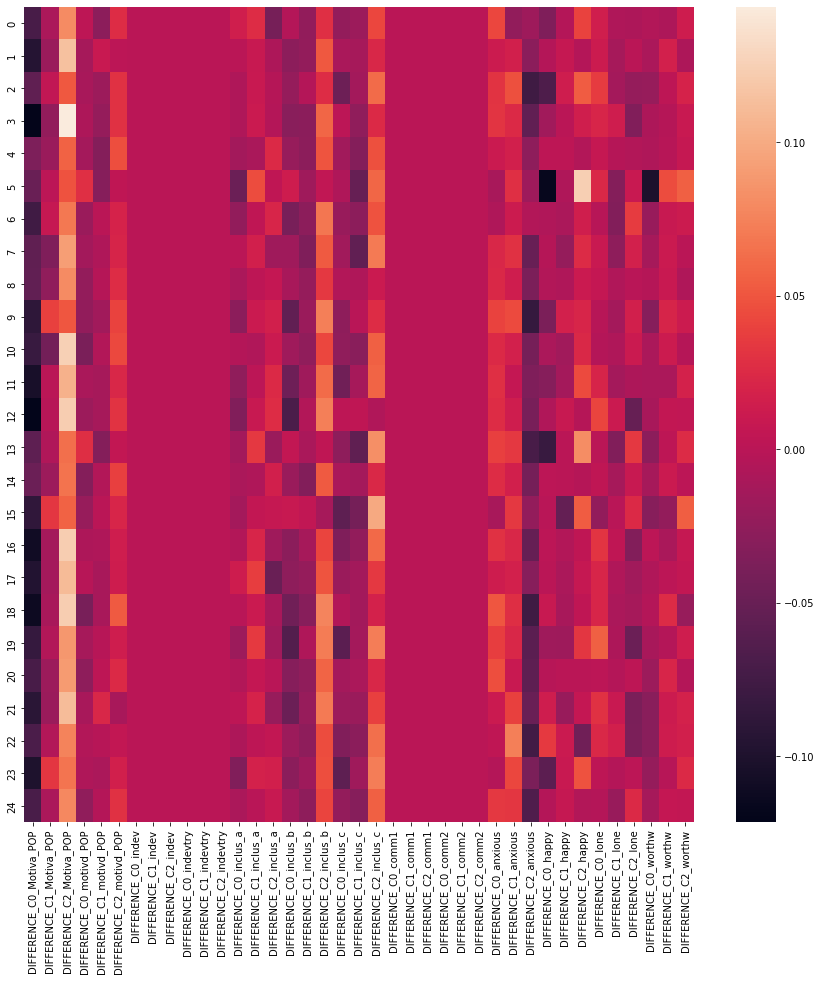

In [32]:
plt.figure(figsize=(15,15))
heat = combined.drop(columns='labels')
sns.heatmap(heat)

In [35]:
class0 = [col for col in combined.columns if 'C0' in col]
class1 = [col for col in combined.columns if 'C1' in col]
class2 = [col for col in combined.columns if 'C2' in col]

<Axes: >

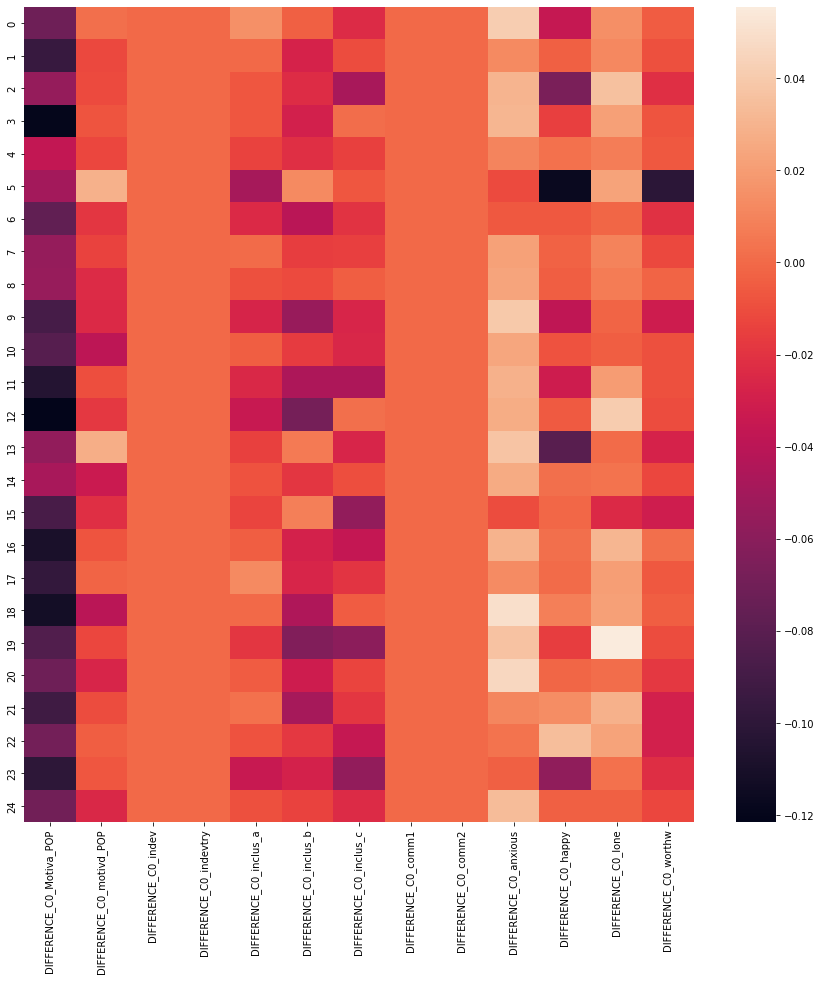

In [36]:
plt.figure(figsize=(15,15))
sns.heatmap(combined[class0])

<Axes: >

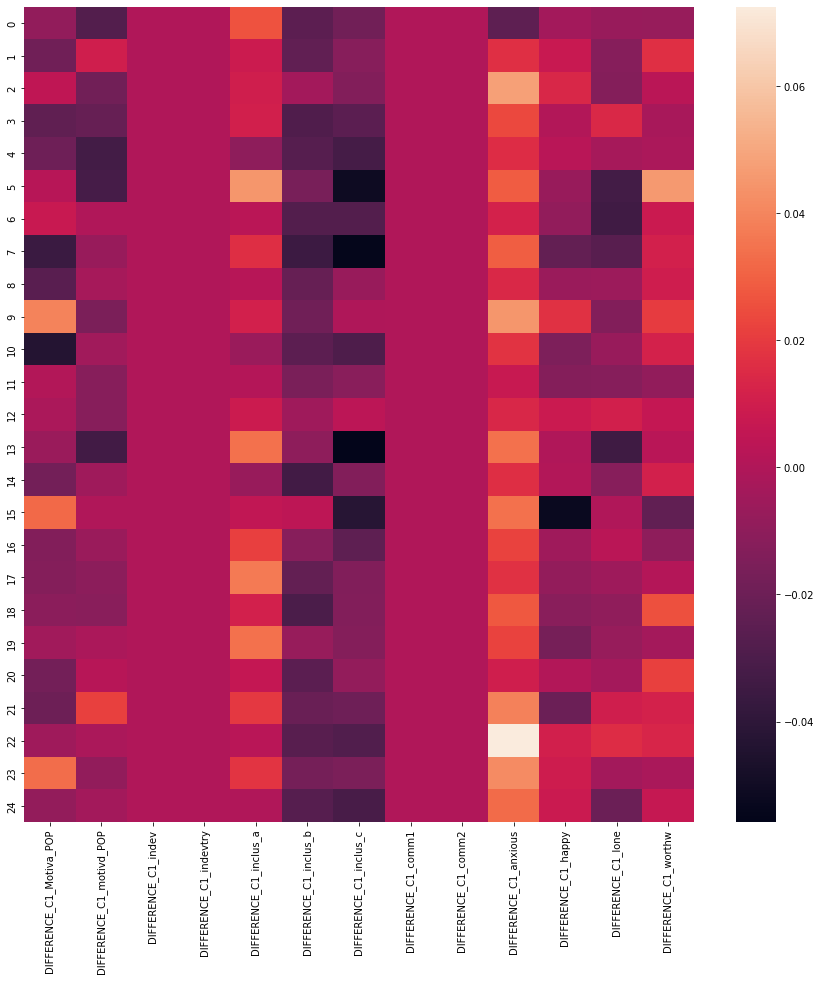

In [37]:
plt.figure(figsize=(15,15))
sns.heatmap(combined[class1])

<Axes: >

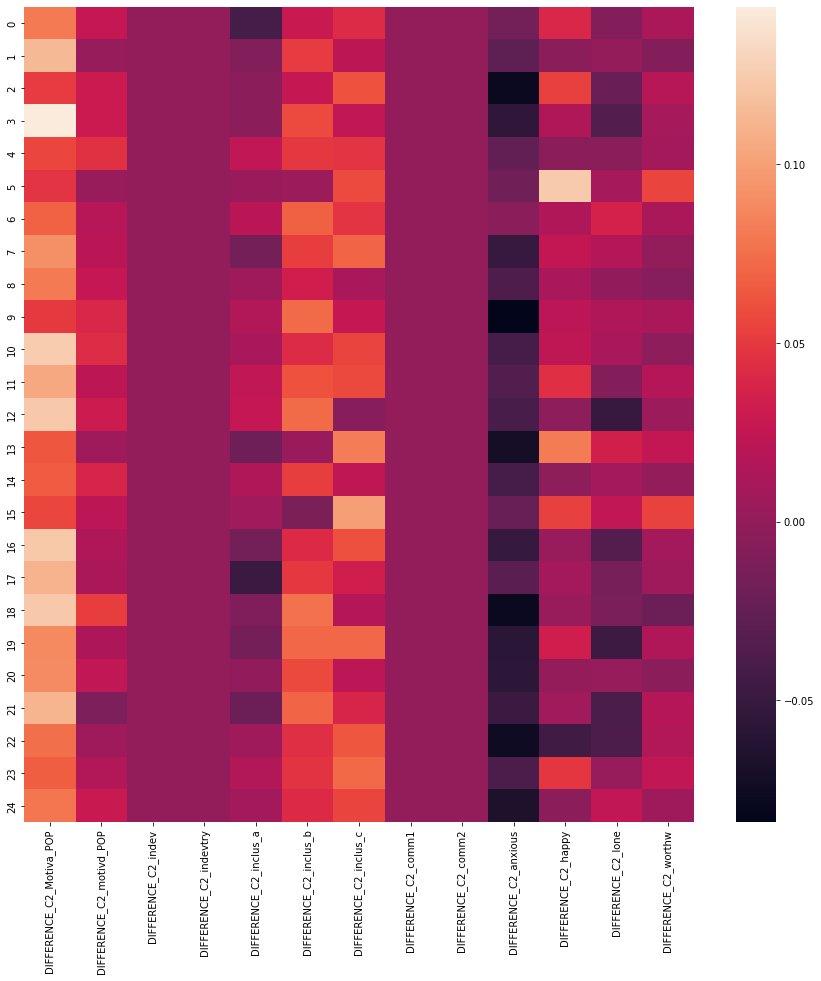

In [38]:
plt.figure(figsize=(15,15))
sns.heatmap(combined[class2])

In [39]:
combined.dtypes

labels                      float64
DIFFERENCE_C0_Motiva_POP    float64
DIFFERENCE_C1_Motiva_POP    float64
DIFFERENCE_C2_Motiva_POP    float64
DIFFERENCE_C0_motivd_POP    float64
DIFFERENCE_C1_motivd_POP    float64
DIFFERENCE_C2_motivd_POP    float64
DIFFERENCE_C0_indev         float64
DIFFERENCE_C1_indev         float64
DIFFERENCE_C2_indev         float64
DIFFERENCE_C0_indevtry      float64
DIFFERENCE_C1_indevtry      float64
DIFFERENCE_C2_indevtry      float64
DIFFERENCE_C0_inclus_a      float64
DIFFERENCE_C1_inclus_a      float64
DIFFERENCE_C2_inclus_a      float64
DIFFERENCE_C0_inclus_b      float64
DIFFERENCE_C1_inclus_b      float64
DIFFERENCE_C2_inclus_b      float64
DIFFERENCE_C0_inclus_c      float64
DIFFERENCE_C1_inclus_c      float64
DIFFERENCE_C2_inclus_c      float64
DIFFERENCE_C0_comm1         float64
DIFFERENCE_C1_comm1         float64
DIFFERENCE_C2_comm1         float64
DIFFERENCE_C0_comm2         float64
DIFFERENCE_C1_comm2         float64
DIFFERENCE_C2_comm2         

In [41]:
combined['labels'] = combined['labels'].astype('category')
combined.dtypes

labels                      category
DIFFERENCE_C0_Motiva_POP     float64
DIFFERENCE_C1_Motiva_POP     float64
DIFFERENCE_C2_Motiva_POP     float64
DIFFERENCE_C0_motivd_POP     float64
DIFFERENCE_C1_motivd_POP     float64
DIFFERENCE_C2_motivd_POP     float64
DIFFERENCE_C0_indev          float64
DIFFERENCE_C1_indev          float64
DIFFERENCE_C2_indev          float64
DIFFERENCE_C0_indevtry       float64
DIFFERENCE_C1_indevtry       float64
DIFFERENCE_C2_indevtry       float64
DIFFERENCE_C0_inclus_a       float64
DIFFERENCE_C1_inclus_a       float64
DIFFERENCE_C2_inclus_a       float64
DIFFERENCE_C0_inclus_b       float64
DIFFERENCE_C1_inclus_b       float64
DIFFERENCE_C2_inclus_b       float64
DIFFERENCE_C0_inclus_c       float64
DIFFERENCE_C1_inclus_c       float64
DIFFERENCE_C2_inclus_c       float64
DIFFERENCE_C0_comm1          float64
DIFFERENCE_C1_comm1          float64
DIFFERENCE_C2_comm1          float64
DIFFERENCE_C0_comm2          float64
DIFFERENCE_C1_comm2          float64
D